In [ ]:
import os
print(os.listdir())

['.config', 'Titanic-Dataset.csv', 'sample_data']


Files in directory:
['.config', 'Titanic-Dataset.csv', 'sample_data']

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113

/tmp/ipykernel_8961/3215658442.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(), inplace=True)
/tmp/ipykernel_8961/3215658442.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

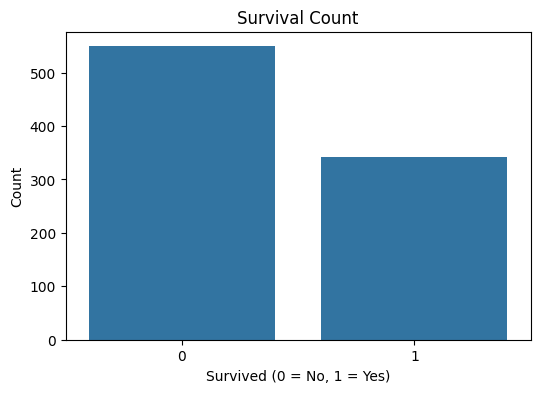

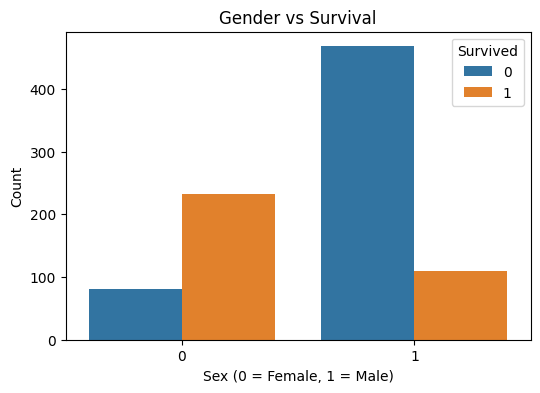

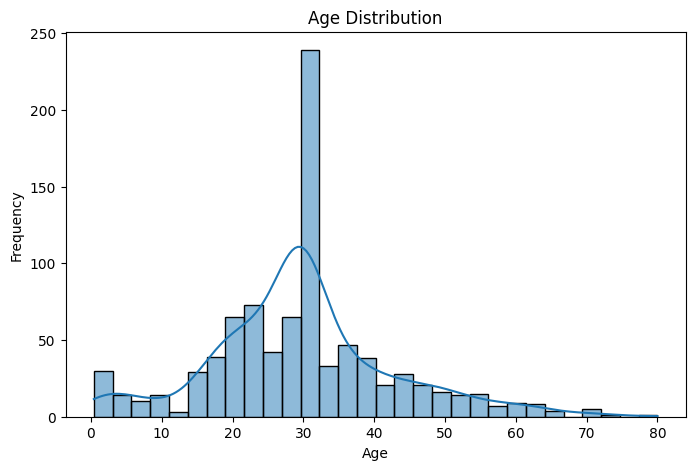

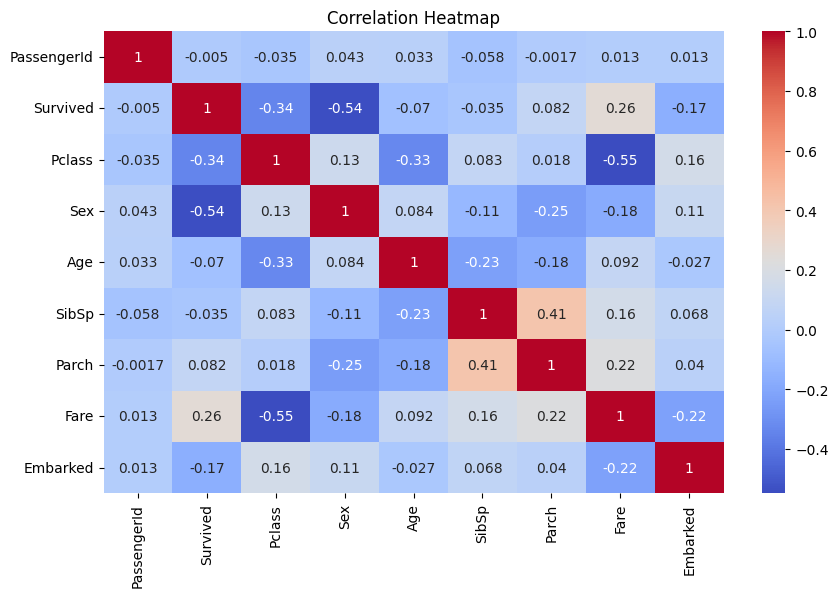


Model Accuracy:
0.8100558659217877


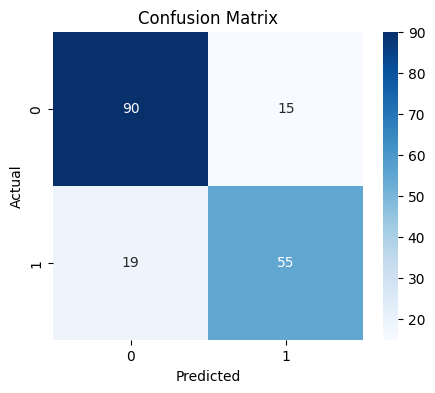

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Check files in directory
print("Files in directory:")
print(os.listdir())

# Load Dataset
data = pd.read_csv("Titanic-Dataset.csv")

# Show first 5 rows
print("\nFirst 5 Rows:")
print(data.head())

# Check Missing Values
print("\nMissing Values:")
print(data.isnull().sum())

# Data Cleaning
data['Age'].fillna(data['Age'].mean(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

# Drop Cabin column
data.drop('Cabin', axis=1, inplace=True)

# Drop remaining null values
data.dropna(inplace=True)

# Encode categorical columns
label = LabelEncoder()

data['Sex'] = label.fit_transform(data['Sex'])
data['Embarked'] = label.fit_transform(data['Embarked'])

# -----------------------------
# GRAPH 1 - Survival Count
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=data)
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# -----------------------------
# GRAPH 2 - Gender vs Survival
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=data)
plt.title("Gender vs Survival")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.show()

# -----------------------------
# GRAPH 3 - Age Distribution
# -----------------------------
plt.figure(figsize=(8,5))
sns.histplot(data['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# GRAPH 4 - Correlation Heatmap
# -----------------------------
# Correlation Heatmap
plt.figure(figsize=(10,6))

# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()
# Feature Selection
X = data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = data['Survived']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("\nModel Accuracy:")
print(accuracy)

# -----------------------------
# GRAPH 5 - Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()